In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/segmented_bank_data.csv')

print(df.shape)

(10000, 15)


In [2]:
country_churn = df.groupby('Geography')['Exited'].mean() * 100

country_churn

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [3]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100

gender_churn

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [4]:
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

age_churn

AgeGroup
30-45    15.300896
46-60    51.123254
60+      24.784483
<30       7.556368
Name: Exited, dtype: float64

In [5]:
tenure_churn = df.groupby('TenureGroup', observed=True)['Exited'].mean() * 100
tenure_churn.sort_values(ascending=False)

TenureGroup
New          21.153846
Long-Term    20.448179
Mid-Term     19.940060
Name: Exited, dtype: float64

In [6]:
balance_churn = df.groupby('BalanceSegment')['Exited'].mean() * 100
balance_churn.sort_values(ascending=False)

BalanceSegment
High Balance    25.234424
Low Balance     20.580808
Zero Balance    13.823611
Name: Exited, dtype: float64

# Customer Churn Analysis

## Overall Churn Rate

The overall customer churn rate is **20.37%**, indicating that approximately one out of every five customers has exited the bank. This highlights a significant customer retention challenge and emphasizes the need for targeted retention strategies.

---

## Geography-wise Churn Findings

| Geography | Churn Rate (%) |
|------------|------------|
| Germany | 32.44 |
| Spain | 16.67 |
| France | 16.15 |

Germany exhibits the highest churn rate at **32.44%**, which is nearly double that of France and Spain. This suggests that the German market represents the highest-risk customer segment and should be prioritized for retention initiatives.

---

## Gender-wise Churn Findings

| Gender | Churn Rate (%) |
|---------|------------|
| Female | 25.07 |
| Male | 16.46 |

Female customers show a significantly higher churn rate (**25.07%**) compared to male customers (**16.46%**). This indicates that female customers may require more targeted engagement and retention strategies.

---

## Age-wise Churn Findings

| Age Group | Churn Rate (%) |
|------------|------------|
| 46-60 | 51.12 |
| 60+ | 24.78 |
| 30-45 | 15.30 |
| <30 | 7.56 |

Customers aged **46–60** have the highest churn rate at **51.12%**, meaning more than half of customers in this age group leave the bank. This age segment represents the most critical churn-risk group.

Customers below 30 years exhibit the lowest churn rate (**7.56%**), suggesting stronger retention among younger customers.

---

## Tenure-wise Churn Findings

| Tenure Group | Churn Rate (%) |
|--------------|------------|
| New | 21.15 |
| Long-Term | 20.45 |
| Mid-Term | 19.94 |

The churn rates across tenure groups are relatively similar. New customers have the highest churn rate at **21.15%**, while mid-term customers show the lowest churn rate at **19.94%**.

This suggests that customer tenure alone is not a major driver of churn in this dataset.

---

## Balance-wise Churn Findings

| Balance Segment | Churn Rate (%) |
|-----------------|------------|
| High Balance | 25.23 |
| Low Balance | 20.58 |
| Zero Balance | 13.82 |

Customers with **high account balances** exhibit the highest churn rate (**25.23%**). This is a critical finding because high-balance customers are likely to contribute significantly to the bank's revenue and profitability.

Customers with zero balance accounts have the lowest churn rate (**13.82%**).

---

## Key Business Insights

1. Germany is the highest-risk geographical segment with a churn rate of 32.44%.
2. Female customers are more likely to churn than male customers.
3. Customers aged 46–60 represent the most vulnerable customer segment, with more than half exiting the bank.
4. New customers show slightly higher churn than long-term customers, but tenure is not a major churn driver.
5. High-balance customers exhibit the highest churn rate, indicating potential revenue risk for the bank.
6. The bank should prioritize retention efforts toward German customers, female customers, customers aged 46–60, and high-balance customers.
7. Reducing churn within these segments could significantly improve customer retention and long-term profitability.

In [7]:
high_value = df[df['Balance'] >= 100000]

print("High Value Customers:", len(high_value))
print("High Value Customer Churn Rate:", round(high_value['Exited'].mean()*100, 2), "%")

High Value Customers: 4799
High Value Customer Churn Rate: 25.23 %


---

## High-Value Customer Churn Analysis

| Metric | Value |
|----------|----------|
| High Value Customers | 4,799 |
| High Value Customer Churn Rate (%) | 25.23 |

High-value customers were defined as customers with account balances greater than or equal to 100,000.

Among 4,799 high-value customers, the churn rate is 25.23%, which is significantly higher than the overall churn rate of 20.37%.

This finding indicates that the bank is losing a substantial portion of its most valuable customers. Since high-balance customers contribute significantly to deposits, cross-selling opportunities, and long-term profitability, their churn represents a major financial risk.

The bank should prioritize retention strategies for high-value customers through personalized services, loyalty programs, relationship management, and targeted engagement campaigns.

---

## Executive Summary

The analysis reveals an overall churn rate of 20.37%, indicating that approximately one in five customers has exited the bank.

Germany emerged as the highest-risk geographic region with a churn rate of 32.44%. Female customers exhibited higher churn rates than male customers, while customers aged 46–60 represented the most vulnerable age segment with a churn rate exceeding 50%.

Tenure showed relatively limited influence on churn behavior. However, customer balance was strongly associated with churn risk. High-balance customers demonstrated the highest churn rate at 25.23%, highlighting a significant revenue risk for the bank.

Based on the findings, retention initiatives should focus on:

1. Customers located in Germany.
2. Female customers.
3. Customers aged 46–60.
4. High-value customers with balances above 100,000.

Targeted retention programs aimed at these segments can help reduce churn, protect revenue, and improve long-term customer loyalty.

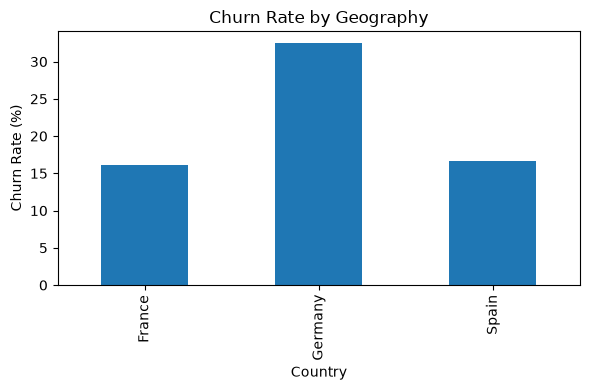

In [8]:
import matplotlib.pyplot as plt

country_churn = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
country_churn.plot(kind='bar')

plt.title("Churn Rate by Geography")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig('../visuals/geography_churn.png')

plt.show()

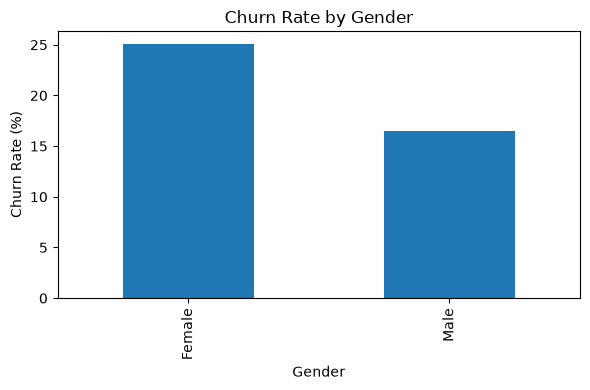

In [9]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
gender_churn.plot(kind='bar')

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig('../visuals/gender_churn.png')

plt.show()

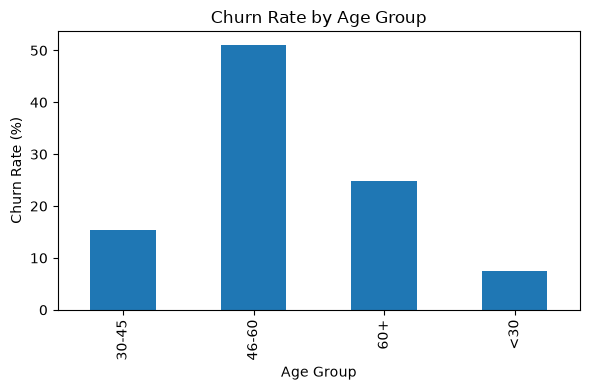

In [10]:
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(6,4))
age_churn.plot(kind='bar')

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig('../visuals/age_churn.png')

plt.show()

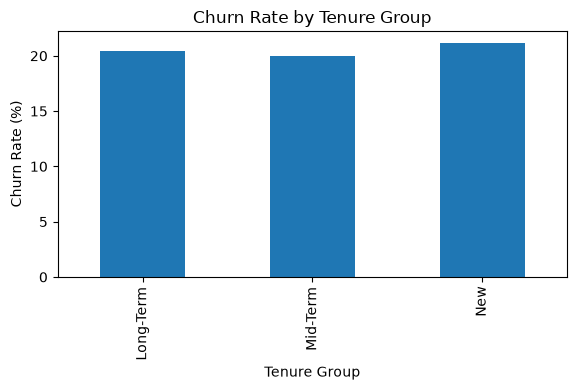

In [11]:
tenure_churn = df.groupby('TenureGroup', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(6,4))
tenure_churn.plot(kind='bar')

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig('../visuals/tenure_churn.png')

plt.show()

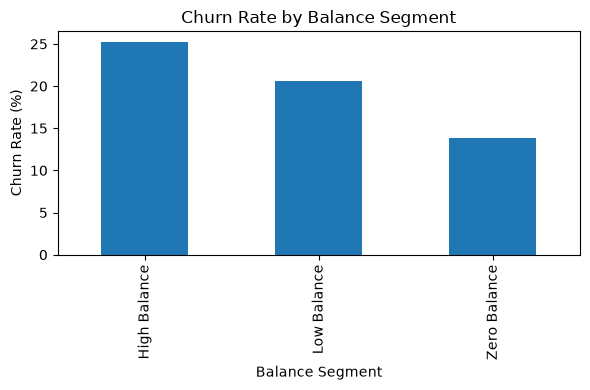

In [12]:
balance_churn = df.groupby('BalanceSegment')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
balance_churn.plot(kind='bar')

plt.title("Churn Rate by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig('../visuals/balance_churn.png')

plt.show()

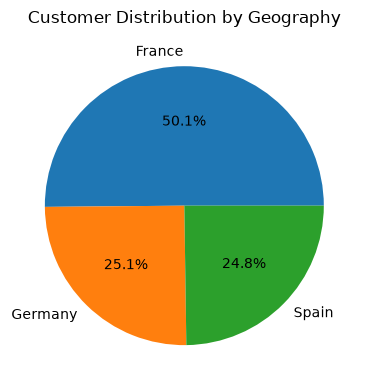

In [13]:
geo_count = df['Geography'].value_counts()

plt.figure(figsize=(6,4))
geo_count.plot(kind='pie', autopct='%1.1f%%')

plt.title("Customer Distribution by Geography")

plt.ylabel("")

plt.tight_layout()

plt.savefig('../visuals/customer_distribution_geography.png')

plt.show()